<a href="https://colab.research.google.com/github/shareotherban/STT-Model/blob/main/STT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("HELLO SPEECH TO TEXT")

HELLO SPEECH TO TEXT


In [ ]:
!git clone https://github.com/Jakobovski/free-spoken-digit-dataset.git

Cloning into 'free-spoken-digit-dataset'...
remote: Enumerating objects: 4260, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 4260 (delta 25), reused 8 (delta 8), pack-reused 4212 (from 1)
Receiving objects: 100% (4260/4260), 30.38 MiB | 25.97 MiB/s, done.
Resolving deltas: 100% (129/129), done.


In [ ]:
import os

#we only tring to train on numbers from 0-9 and it has 3000 recording that it saying it in 3000 diff ways
digit_to_word = {
    '0': 'zero', '1': 'one', '2': 'two', '3': 'three', '4': 'four',
    '5': 'five', '6': 'six', '7': 'seven', '8': 'eight', '9': 'nine'
}

recordings_dir = 'free-spoken-digit-dataset/recordings'
filenames = sorted(os.listdir(recordings_dir))

file_labels = []
for fname in filenames:
    digit = fname.split('_')[0]
    label = digit_to_word[digit]
    file_labels.append((os.path.join(recordings_dir, fname), label))

print(len(file_labels), 'clips found')
print(file_labels[0])

3000 clips found
('free-spoken-digit-dataset/recordings/0_george_0.wav', 'zero')


In [ ]:
import wave
import numpy as np

def load_wav(path):
    with wave.open(path, 'rb') as wf:
        sample_rate = wf.getframerate()
        n_frames = wf.getnframes()
        raw_bytes = wf.readframes(n_frames)
    # These clips are 16-bit PCM, mono -> each sample is a signed 2-byte int
    samples = np.frombuffer(raw_bytes, dtype=np.int16)
    # Normalize int16 range [-32768, 32767] to roughly [-1, 1]
    waveform = samples.astype(np.float32) / 32768.0
    return waveform, sample_rate

wav, sr = load_wav(file_labels[0][0])
print(wav.shape, wav.dtype, sr)

(2384,) float32 8000


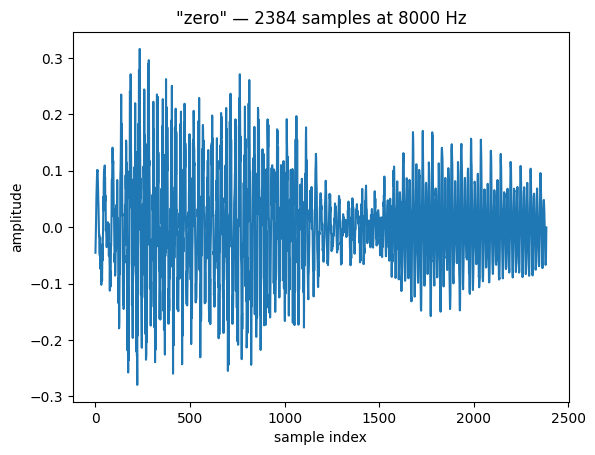

In [ ]:
import matplotlib.pyplot as plt

plt.plot(wav)
plt.title(f'"{file_labels[0][1]}" — {len(wav)} samples at {sr} Hz')
plt.xlabel('sample index')
plt.ylabel('amplitude')
plt.show()

In [ ]:
import random

dataset = []
for path, label in file_labels:
    waveform, sr = load_wav(path)
    dataset.append((waveform, label))

random.seed(42)
random.shuffle(dataset)
# we use 80% of the data to train
split_idx = int(0.8 * len(dataset))
train_set = dataset[:split_idx]
test_set = dataset[split_idx:]

print(f'train: {len(train_set)}, test: {len(test_set)}')
print('example label:', train_set[0][1])

train: 2400, test: 600
example label: eight


In [ ]:
def compute_spectrogram(waveform, sample_rate, frame_ms=25, hop_ms=10):
    frame_len = int(sample_rate * frame_ms / 1000)   # samples per frame
    hop_len = int(sample_rate * hop_ms / 1000)        # samples per step

    window = np.hamming(frame_len)  # taper shape, one fixed math primitive

    n_frames = max(1, 1 + (len(waveform) - frame_len) // hop_len)

    spectrogram = []
    for i in range(n_frames):
        start = i * hop_len
        frame = waveform[start:start + frame_len]
        if len(frame) < frame_len:                     # pad the last frame if short
            frame = np.pad(frame, (0, frame_len - len(frame)))

        windowed = frame * window                       # apply taper
        spectrum = np.fft.rfft(windowed)                 # time -> frequency
        magnitude = np.abs(spectrum)                     # we only care about energy, not phase
        log_magnitude = np.log1p(magnitude)               # log(1+x): compress dynamic range, avoid log(0)

        spectrogram.append(log_magnitude)

    return np.array(spectrogram)  # shape: (n_frames, freq_bins)

(28, 101)


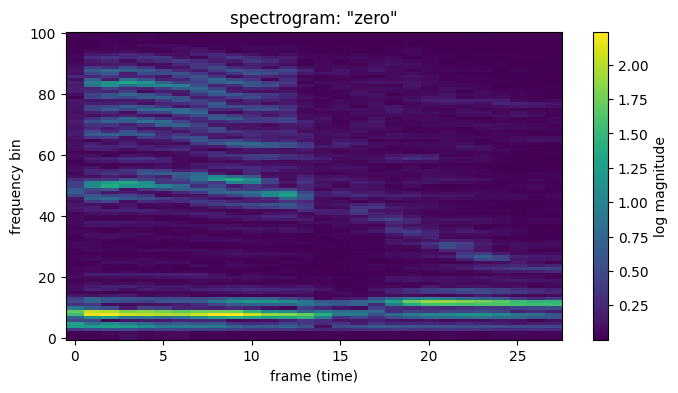

In [ ]:
spec = compute_spectrogram(wav, sr)
print(spec.shape)

plt.figure(figsize=(8, 4))
plt.imshow(spec.T, aspect='auto', origin='lower', cmap='viridis')
plt.xlabel('frame (time)')
plt.ylabel('frequency bin')
plt.title(f'spectrogram: "{file_labels[0][1]}"')
plt.colorbar(label='log magnitude')
plt.show()

In [ ]:
all_labels = [label for _, label in train_set] + [label for _, label in test_set]
chars = sorted(set(''.join(all_labels)))

BLANK = '<blank>'
vocab = [BLANK] + chars
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}
blank_idx = char_to_idx[BLANK]

print(vocab)
print('blank index:', blank_idx)
print('vocab size:', len(vocab))

['<blank>', 'e', 'f', 'g', 'h', 'i', 'n', 'o', 'r', 's', 't', 'u', 'v', 'w', 'x', 'z']
blank index: 0
vocab size: 16


In [ ]:
def encode_label(text):
    return np.array([char_to_idx[ch] for ch in text], dtype=np.int64)

def decode_label(indices):
    return ''.join(idx_to_char[int(i)] for i in indices)

In [ ]:
example_label = train_set[0][1]
encoded = encode_label(example_label)
decoded = decode_label(encoded)

print(example_label, '->', encoded, '->', decoded)
assert decoded == example_label, "round-trip failed!"

eight -> [ 1  5  3  4 10] -> eight


In [ ]:
input_dim = spec.shape[1]      # 101 frequency bins
hidden_dim = 64                # size of the memory — a knob you can tune later
vocab_size = len(vocab)        # 16

def init_rnn_params(input_dim, hidden_dim, vocab_size, seed=42):
    rng = np.random.default_rng(seed)
    scale_xh = 1.0 / np.sqrt(input_dim)
    scale_hh = 1.0 / np.sqrt(hidden_dim)
    scale_hy = 1.0 / np.sqrt(hidden_dim)

    return {
        'W_xh': rng.uniform(-scale_xh, scale_xh, (hidden_dim, input_dim)),
        'W_hh': rng.uniform(-scale_hh, scale_hh, (hidden_dim, hidden_dim)),
        'b_h':  np.zeros(hidden_dim),
        'W_hy': rng.uniform(-scale_hy, scale_hy, (vocab_size, hidden_dim)),
        'b_y':  np.zeros(vocab_size),
    }

params = init_rnn_params(input_dim, hidden_dim, vocab_size)

In [ ]:
def softmax(x):
    x_shifted = x - np.max(x, axis=-1, keepdims=True)  # numerical stability
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def rnn_forward(spec, params):
    T = spec.shape[0]
    hidden_dim = params['W_hh'].shape[0]

    h = np.zeros(hidden_dim)     # hidden state starts at zero
    hidden_states = [h]          # we'll need every h_t for backprop later (Phase 6)
    logits = []

    for t in range(T):
        x_t = spec[t]
        h = np.tanh(params['W_xh'] @ x_t + params['W_hh'] @ h + params['b_h'])
        y_t = params['W_hy'] @ h + params['b_y']
        hidden_states.append(h)
        logits.append(y_t)

    logits = np.array(logits)        # (T, vocab_size)
    probs = softmax(logits)          # per-frame probability distribution
    return probs, np.array(hidden_states)

In [ ]:
probs, hidden_states = rnn_forward(spec, params)   # reusing spec from Phase 2

print('probs shape:', probs.shape)
print('each row sums to 1:', np.allclose(probs.sum(axis=1), 1.0))
print('first frame distribution:', probs[0])

probs shape: (28, 16)
each row sums to 1: True
first frame distribution: [0.06049702 0.06188434 0.05809001 0.07159749 0.0637949  0.06265762
 0.05543783 0.06320044 0.06295941 0.05924591 0.06474494 0.07627091
 0.05298169 0.06133434 0.06334094 0.06196221]


In [ ]:
def make_extended_labels(encoded_label, blank_idx):
    extended = [blank_idx]
    for l in encoded_label:
        extended.append(l)
        extended.append(blank_idx)
    return np.array(extended)

In [ ]:
def ctc_forward(probs, extended_labels, blank_idx):
    T = probs.shape[0]
    S = len(extended_labels)
    alpha = np.zeros((T, S))

    # base case: t = 0, only the first blank and first real symbol are reachable
    alpha[0, 0] = probs[0, extended_labels[0]]
    if S > 1:
        alpha[0, 1] = probs[0, extended_labels[1]]

    for t in range(1, T):
        for s in range(S):
            a = alpha[t-1, s]                        # stay
            if s > 0:
                a += alpha[t-1, s-1]                  # advance
            if s > 1 and extended_labels[s] != blank_idx and extended_labels[s] != extended_labels[s-2]:
                a += alpha[t-1, s-2]                  # skip the blank (only for two DIFFERENT letters)
            alpha[t, s] = a * probs[t, extended_labels[s]]

    # path must end on either the very last symbol or the trailing blank after it
    total_prob = alpha[T-1, S-1]
    if S > 1:
        total_prob += alpha[T-1, S-2]

    return alpha, total_prob

In [ ]:
def ctc_loss(probs, encoded_label, blank_idx):
    extended_labels = make_extended_labels(encoded_label, blank_idx)
    alpha, total_prob = ctc_forward(probs, extended_labels, blank_idx)
    loss = -np.log(total_prob + 1e-12)   # epsilon guards against log(0)
    return loss, alpha, extended_labels

extended labels: [ 0 15  0  1  0  8  0  7  0]
total_prob (should be between 0 and 1): 1.000000000000001e-12
loss: 27.631021115928547


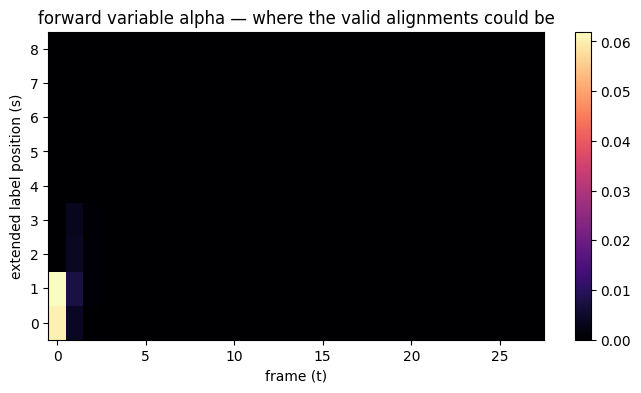

In [ ]:
example_label = file_labels[0][1]              # 'zero' — matches the wav/spec/probs already in memory
encoded_label = encode_label(example_label)

loss, alpha, extended_labels = ctc_loss(probs, encoded_label, blank_idx)

print('extended labels:', extended_labels)
print('total_prob (should be between 0 and 1):', np.exp(-loss))
print('loss:', loss)

plt.figure(figsize=(8, 4))
plt.imshow(alpha.T, aspect='auto', origin='lower', cmap='magma')
plt.xlabel('frame (t)')
plt.ylabel('extended label position (s)')
plt.title('forward variable alpha — where the valid alignments could be')
plt.colorbar()
plt.show()

In [ ]:
def logsumexp(*values):
    values = [v for v in values if v != -np.inf]
    if not values:
        return -np.inf
    m = max(values)
    return m + np.log(sum(np.exp(v - m) for v in values))

In [ ]:
def ctc_forward_log(log_probs, extended_labels, blank_idx):
    T = log_probs.shape[0]
    S = len(extended_labels)
    log_alpha = np.full((T, S), -np.inf)   # -inf represents log(0) — "impossible"

    log_alpha[0, 0] = log_probs[0, extended_labels[0]]
    if S > 1:
        log_alpha[0, 1] = log_probs[0, extended_labels[1]]

    for t in range(1, T):
        for s in range(S):
            candidates = [log_alpha[t-1, s]]                      # stay
            if s > 0:
                candidates.append(log_alpha[t-1, s-1])            # advance
            if s > 1 and extended_labels[s] != blank_idx and extended_labels[s] != extended_labels[s-2]:
                candidates.append(log_alpha[t-1, s-2])             # skip (only for two different letters)
            log_alpha[t, s] = logsumexp(*candidates) + log_probs[t, extended_labels[s]]

    if S > 1:
        total_log_prob = logsumexp(log_alpha[T-1, S-1], log_alpha[T-1, S-2])
    else:
        total_log_prob = log_alpha[T-1, S-1]

    return log_alpha, total_log_prob

def ctc_loss_log(probs, encoded_label, blank_idx):
    extended_labels = make_extended_labels(encoded_label, blank_idx)
    log_probs = np.log(probs + 1e-12)   # this epsilon is fine — it's just guarding a single log(0), not accumulating
    log_alpha, total_log_prob = ctc_forward_log(log_probs, extended_labels, blank_idx)
    loss = -total_log_prob
    return loss, log_alpha, extended_labels

loss: 62.059580319299016


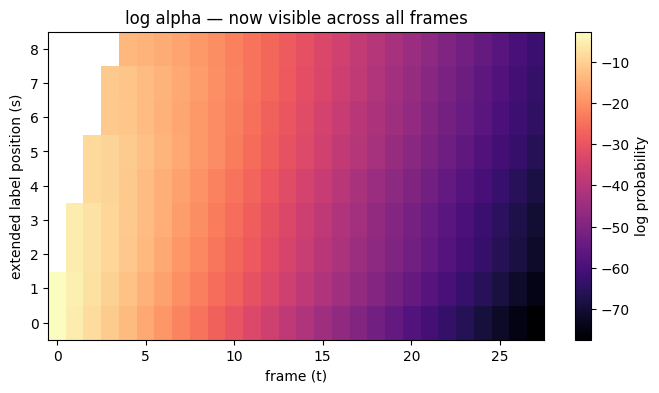

In [ ]:
loss, log_alpha, extended_labels = ctc_loss_log(probs, encoded_label, blank_idx)

print('loss:', loss)

plt.figure(figsize=(8, 4))
plt.imshow(log_alpha.T, aspect='auto', origin='lower', cmap='magma')
plt.xlabel('frame (t)')
plt.ylabel('extended label position (s)')
plt.title('log alpha — now visible across all frames')
plt.colorbar(label='log probability')
plt.show()

In [ ]:
def ctc_backward_log(log_probs, extended_labels, blank_idx):
    T = log_probs.shape[0]
    S = len(extended_labels)
    log_beta = np.full((T, S), -np.inf)

    log_beta[T-1, S-1] = log_probs[T-1, extended_labels[S-1]]
    if S > 1:
        log_beta[T-1, S-2] = log_probs[T-1, extended_labels[S-2]]

    for t in range(T-2, -1, -1):
        for s in range(S):
            candidates = [log_beta[t+1, s]]                    # stay
            if s < S - 1:
                candidates.append(log_beta[t+1, s+1])           # advance
            if s < S - 2 and extended_labels[s] != blank_idx and extended_labels[s+2] != extended_labels[s]:
                candidates.append(log_beta[t+1, s+2])            # skip (two different letters only)
            log_beta[t, s] = logsumexp(*candidates) + log_probs[t, extended_labels[s]]

    return log_beta

In [ ]:
def ctc_gradient(probs, encoded_label, blank_idx):
    extended_labels = make_extended_labels(encoded_label, blank_idx)
    log_probs = np.log(probs + 1e-12)

    log_alpha, total_log_prob = ctc_forward_log(log_probs, extended_labels, blank_idx)
    log_beta = ctc_backward_log(log_probs, extended_labels, blank_idx)

    T, vocab_size = probs.shape
    S = len(extended_labels)

    emission_log_probs = log_probs[:, extended_labels]              # (T, S)
    log_gamma = log_alpha + log_beta - emission_log_probs - total_log_prob
    gamma = np.exp(log_gamma)                                        # (T, S) posterior per position

    target_posterior = np.zeros((T, vocab_size))
    for s in range(S):
        target_posterior[:, extended_labels[s]] += gamma[:, s]

    grad_logits = probs - target_posterior                           # (T, vocab_size)
    loss = -total_log_prob
    return loss, grad_logits

In [ ]:
def rnn_forward(spec, params):
    T = spec.shape[0]
    hidden_dim = params['W_hh'].shape[0]
    h = np.zeros(hidden_dim)
    hidden_states = [h]
    logits = []
    for t in range(T):
        x_t = spec[t]
        h = np.tanh(params['W_xh'] @ x_t + params['W_hh'] @ h + params['b_h'])
        y_t = params['W_hy'] @ h + params['b_y']
        hidden_states.append(h)
        logits.append(y_t)
    logits = np.array(logits)
    probs = softmax(logits)
    return probs, logits, np.array(hidden_states)   # now also returns raw logits

probs, logits, hidden_states = rnn_forward(spec, params)

In [ ]:
def loss_from_logits(logits, encoded_label, blank_idx):
    probs = softmax(logits)
    extended_labels = make_extended_labels(encoded_label, blank_idx)
    log_probs = np.log(probs + 1e-12)
    _, total_log_prob = ctc_forward_log(log_probs, extended_labels, blank_idx)
    return -total_log_prob

loss, grad_logits = ctc_gradient(probs, encoded_label, blank_idx)
print('loss (should match Phase 5 part 1):', loss)

rng = np.random.default_rng(0)
eps = 1e-4
for _ in range(5):
    t = rng.integers(0, logits.shape[0])
    k = rng.integers(0, logits.shape[1])

    logits_plus = logits.copy();  logits_plus[t, k]  += eps
    logits_minus = logits.copy(); logits_minus[t, k] -= eps

    numerical_grad = (loss_from_logits(logits_plus, encoded_label, blank_idx) -
                       loss_from_logits(logits_minus, encoded_label, blank_idx)) / (2 * eps)

    print(f't={t:2d}, k={k:2d}  analytical={grad_logits[t,k]: .6f}  numerical={numerical_grad: .6f}')

loss (should match Phase 5 part 1): 62.059580319299016
t=23, k=10  analytical= 0.070667  numerical= 0.070667
t=14, k= 4  analytical= 0.064077  numerical= 0.064077
t= 8, k= 0  analytical=-0.375146  numerical=-0.375146
t= 2, k= 0  analytical=-0.526532  numerical=-0.526532
t= 4, k=13  analytical= 0.055439  numerical= 0.055439


In [ ]:
def backprop_rnn(spec, hidden_states, grad_logits, params):
    T = spec.shape[0]
    hidden_dim = params['W_hh'].shape[0]

    grads = {k: np.zeros_like(v) for k, v in params.items()}
    dh_next = np.zeros(hidden_dim)   # gradient flowing back from the future — starts at zero at the last frame

    for t in reversed(range(T)):
        dy_t = grad_logits[t]
        h_t = hidden_states[t + 1]     # hidden state produced at this timestep
        h_prev = hidden_states[t]      # hidden state fed INTO this timestep

        grads['W_hy'] += np.outer(dy_t, h_t)
        grads['b_y']  += dy_t

        dh = params['W_hy'].T @ dy_t + dh_next        # direct + recurrent contributions
        dtanh = (1 - h_t ** 2) * dh                    # derivative of tanh

        grads['b_h']  += dtanh
        grads['W_xh'] += np.outer(dtanh, spec[t])
        grads['W_hh'] += np.outer(dtanh, h_prev)

        dh_next = params['W_hh'].T @ dtanh              # pass gradient back to t-1

    return grads

In [ ]:
def clip_gradients(grads, max_norm=5.0):
    total_norm = np.sqrt(sum(np.sum(g ** 2) for g in grads.values()))
    if total_norm > max_norm:
        scale = max_norm / (total_norm + 1e-8)
        for k in grads:
            grads[k] *= scale
    return grads

In [ ]:
def train_step(spec, encoded_label, params, blank_idx, lr=0.05):
    probs, logits, hidden_states = rnn_forward(spec, params)
    loss, grad_logits = ctc_gradient(probs, encoded_label, blank_idx)
    grads = backprop_rnn(spec, hidden_states, grad_logits, params)
    grads = clip_gradients(grads)

    for k in params:
        params[k] -= lr * grads[k]   # plain SGD

    return loss

epoch   0  avg loss 31.228
epoch   5  avg loss 10.813
epoch  10  avg loss 9.098
epoch  15  avg loss 22.695
epoch  20  avg loss 7.514
epoch  25  avg loss 7.372
epoch  30  avg loss 6.597
epoch  35  avg loss 6.033


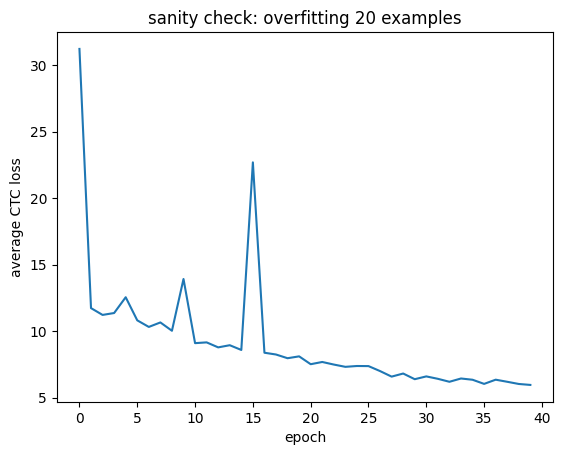

In [ ]:
import random

subset = train_set[:20]
subset_data = [(compute_spectrogram(wf, sr), encode_label(lbl)) for wf, lbl in subset]

params = init_rnn_params(input_dim, hidden_dim, vocab_size)  # fresh weights
loss_history = []

for epoch in range(40):
    random.shuffle(subset_data)
    epoch_loss = 0.0
    for spec_feat, enc_label in subset_data:
        loss = train_step(spec_feat, enc_label, params, blank_idx, lr=0.05)
        epoch_loss += loss
    avg_loss = epoch_loss / len(subset_data)
    loss_history.append(avg_loss)
    if epoch % 5 == 0:
        print(f'epoch {epoch:3d}  avg loss {avg_loss:.3f}')

plt.plot(loss_history)
plt.xlabel('epoch')
plt.ylabel('average CTC loss')
plt.title('sanity check: overfitting 20 examples')
plt.show()

In [ ]:
def init_adam_state(params):
    return {
        'm': {k: np.zeros_like(v) for k, v in params.items()},   # running mean of gradient
        'v': {k: np.zeros_like(v) for k, v in params.items()},   # running mean of gradient^2
        't': 0
    }

def adam_update(params, grads, state, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
    state['t'] += 1
    t = state['t']
    for k in params:
        state['m'][k] = beta1 * state['m'][k] + (1 - beta1) * grads[k]
        state['v'][k] = beta2 * state['v'][k] + (1 - beta2) * (grads[k] ** 2)
        m_hat = state['m'][k] / (1 - beta1 ** t)   # bias correction — m,v start at 0, this compensates
        v_hat = state['v'][k] / (1 - beta2 ** t)
        params[k] -= lr * m_hat / (np.sqrt(v_hat) + eps)

In [ ]:
def train_step(spec, encoded_label, params, blank_idx, adam_state, lr=0.01):
    probs, logits, hidden_states = rnn_forward(spec, params)
    loss, grad_logits = ctc_gradient(probs, encoded_label, blank_idx)
    grads = backprop_rnn(spec, hidden_states, grad_logits, params)
    grads = clip_gradients(grads)
    adam_update(params, grads, adam_state, lr=lr)
    return loss

epoch   0  avg loss 25.5502
epoch  15  avg loss 8.3121
epoch  30  avg loss 43.9578
epoch  45  avg loss 3.0309
epoch  60  avg loss 2.2186
epoch  75  avg loss 1.3260
epoch  90  avg loss 1.4130
epoch 105  avg loss 0.6498
epoch 120  avg loss 0.5123
epoch 135  avg loss 1.1669


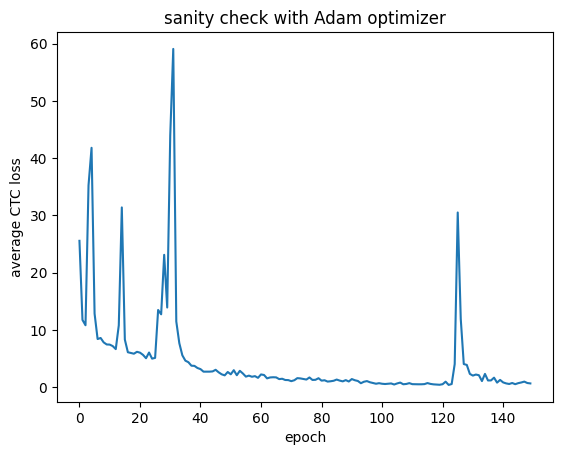

In [ ]:
params = init_rnn_params(input_dim, hidden_dim, vocab_size)  # fresh weights
adam_state = init_adam_state(params)
loss_history = []

for epoch in range(150):
    random.shuffle(subset_data)
    epoch_loss = 0.0
    for spec_feat, enc_label in subset_data:
        loss = train_step(spec_feat, enc_label, params, blank_idx, adam_state, lr=0.01)
        epoch_loss += loss
    avg_loss = epoch_loss / len(subset_data)
    loss_history.append(avg_loss)
    if epoch % 15 == 0:
        print(f'epoch {epoch:3d}  avg loss {avg_loss:.4f}')

plt.plot(loss_history)
plt.xlabel('epoch')
plt.ylabel('average CTC loss')
plt.title('sanity check with Adam optimizer')
plt.show()

epoch   0  avg loss 30.3346
epoch  15  avg loss 6.5228
epoch  30  avg loss 4.1328
epoch  45  avg loss 3.1202
epoch  60  avg loss 2.0291
epoch  75  avg loss 1.4138
epoch  90  avg loss 1.5409
epoch 105  avg loss 1.5912
epoch 120  avg loss 0.7916
epoch 135  avg loss 1.2968


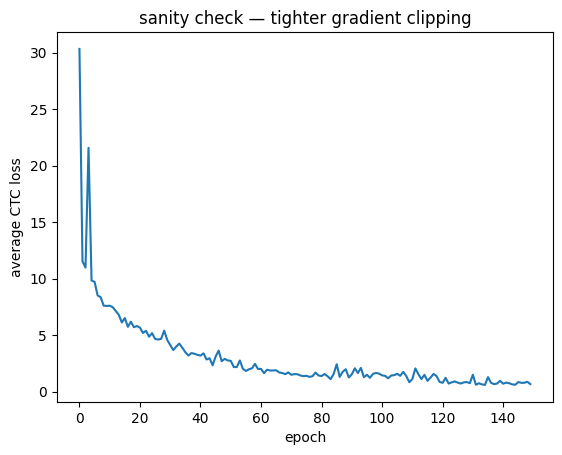

In [ ]:
def train_step(spec, encoded_label, params, blank_idx, adam_state, lr=0.01):
    probs, logits, hidden_states = rnn_forward(spec, params)
    loss, grad_logits = ctc_gradient(probs, encoded_label, blank_idx)
    grads = backprop_rnn(spec, hidden_states, grad_logits, params)
    grads = clip_gradients(grads, max_norm=1.5)   # tightened from 5.0
    adam_update(params, grads, adam_state, lr=lr)
    return loss

params = init_rnn_params(input_dim, hidden_dim, vocab_size)
adam_state = init_adam_state(params)
loss_history = []

for epoch in range(150):
    random.shuffle(subset_data)
    epoch_loss = 0.0
    for spec_feat, enc_label in subset_data:
        loss = train_step(spec_feat, enc_label, params, blank_idx, adam_state, lr=0.01)
        epoch_loss += loss
    avg_loss = epoch_loss / len(subset_data)
    loss_history.append(avg_loss)
    if epoch % 15 == 0:
        print(f'epoch {epoch:3d}  avg loss {avg_loss:.4f}')

plt.plot(loss_history)
plt.xlabel('epoch')
plt.ylabel('average CTC loss')
plt.title('sanity check — tighter gradient clipping')
plt.show()

In [ ]:
print('computing spectrograms for the full dataset...')
train_data = [(compute_spectrogram(wf, sample_rate=8000), encode_label(lbl)) for wf, lbl in train_set]
test_data  = [(compute_spectrogram(wf, sample_rate=8000), encode_label(lbl)) for wf, lbl in test_set]
print('done:', len(train_data), 'train,', len(test_data), 'test')

computing spectrograms for the full dataset...
done: 2400 train, 600 test


In [ ]:
def evaluate_loss(data, params, blank_idx, sample_size=200):
    sample = random.sample(data, min(sample_size, len(data)))
    total = 0.0
    for spec_feat, enc_label in sample:
        probs, logits, _ = rnn_forward(spec_feat, params)
        loss, _ = ctc_gradient(probs, enc_label, blank_idx)
        total += loss
    return total / len(sample)

In [ ]:
params = init_rnn_params(input_dim, hidden_dim, vocab_size)
adam_state = init_adam_state(params)

train_loss_history = []
test_loss_history = []

n_epochs = 15   # start here — see the timing note below before going bigger

for epoch in range(n_epochs):
    random.shuffle(train_data)
    epoch_loss = 0.0
    for spec_feat, enc_label in train_data:
        loss = train_step(spec_feat, enc_label, params, blank_idx, adam_state, lr=0.01)
        epoch_loss += loss
    avg_train_loss = epoch_loss / len(train_data)
    avg_test_loss = evaluate_loss(test_data, params, blank_idx)

    train_loss_history.append(avg_train_loss)
    test_loss_history.append(avg_test_loss)
    print(f'epoch {epoch:2d}  train loss {avg_train_loss:.4f}  test loss {avg_test_loss:.4f}')

    np.savez('ctc_rnn_checkpoint.npz', **params)   # save after every epoch — Colab can disconnect

epoch  0  train loss 10.0670  test loss 9.4316
epoch  1  train loss 7.0483  test loss 5.7460
epoch  2  train loss 6.8423  test loss 8.2999
epoch  3  train loss 6.7814  test loss 7.3988
epoch  4  train loss 6.6783  test loss 7.4906
epoch  5  train loss 6.6626  test loss 7.3374
epoch  6  train loss 6.4901  test loss 6.9233
epoch  7  train loss 6.4227  test loss 6.2233
epoch  8  train loss 6.4065  test loss 7.8794
epoch  9  train loss 6.8294  test loss 7.8767
epoch 10  train loss 6.4615  test loss 8.5544
epoch 11  train loss 6.4465  test loss 6.8261
epoch 12  train loss 6.2290  test loss 6.3816
epoch 13  train loss 6.2685  test loss 6.6926
epoch 14  train loss 6.1217  test loss 6.8324


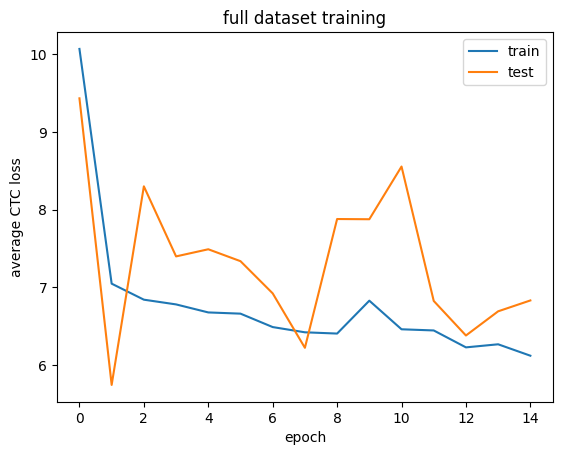

In [ ]:
plt.plot(train_loss_history, label='train')
plt.plot(test_loss_history, label='test')
plt.xlabel('epoch')
plt.ylabel('average CTC loss')
plt.legend()
plt.title('full dataset training')
plt.show()

In [ ]:
eval_subset = random.sample(test_data, 200)   # pick once, reuse every epoch

def evaluate_loss_fixed(params, blank_idx):
    total = 0.0
    for spec_feat, enc_label in eval_subset:
        probs, logits, _ = rnn_forward(spec_feat, params)
        loss, _ = ctc_gradient(probs, enc_label, blank_idx)
        total += loss
    return total / len(eval_subset)

In [ ]:
params = dict(np.load('ctc_rnn_checkpoint.npz'))

epoch 17  train loss 6.3449  test loss 7.1548
epoch 18  train loss 6.2932  test loss 6.4550
epoch 19  train loss 6.0177  test loss 6.4525
epoch 20  train loss 6.1388  test loss 7.8181
epoch 21  train loss 5.9527  test loss 6.6191
epoch 22  train loss 6.5263  test loss 7.2747
epoch 23  train loss 6.5624  test loss 6.6128
epoch 24  train loss 6.1192  test loss 8.0968
epoch 25  train loss 6.2168  test loss 6.3679
epoch 26  train loss 6.0107  test loss 7.0696
epoch 27  train loss 6.2040  test loss 6.4514
epoch 28  train loss 6.0226  test loss 6.6018
epoch 29  train loss 5.9984  test loss 6.5187
epoch 30  train loss 5.8883  test loss 7.4596
epoch 31  train loss 5.9228  test loss 7.6173
epoch 32  train loss 6.2120  test loss 7.1156
epoch 33  train loss 6.2684  test loss 7.1495
epoch 34  train loss 6.0882  test loss 7.6849
epoch 35  train loss 6.0498  test loss 7.0192
epoch 36  train loss 5.8332  test loss 6.2672


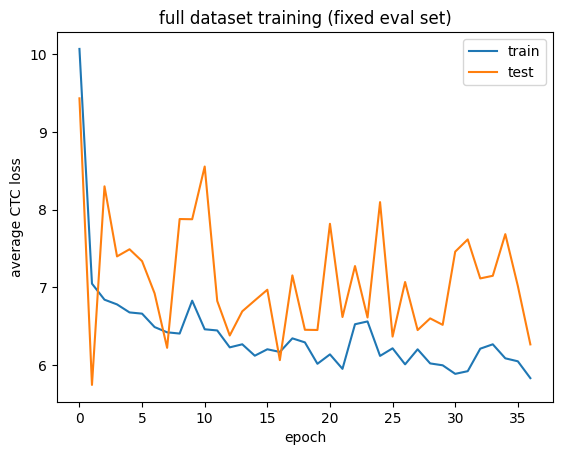

In [ ]:
n_more_epochs = 20

for epoch in range(n_more_epochs):
    random.shuffle(train_data)
    epoch_loss = 0.0
    for spec_feat, enc_label in train_data:
        loss = train_step(spec_feat, enc_label, params, blank_idx, adam_state, lr=0.01)
        epoch_loss += loss
    avg_train_loss = epoch_loss / len(train_data)
    avg_test_loss = evaluate_loss_fixed(params, blank_idx)

    train_loss_history.append(avg_train_loss)
    test_loss_history.append(avg_test_loss)
    print(f'epoch {len(train_loss_history)-1:2d}  train loss {avg_train_loss:.4f}  test loss {avg_test_loss:.4f}')

    np.savez('ctc_rnn_checkpoint.npz', **params)

plt.plot(train_loss_history, label='train')
plt.plot(test_loss_history, label='test')
plt.xlabel('epoch')
plt.ylabel('average CTC loss')
plt.legend()
plt.title('full dataset training (fixed eval set)')
plt.show()

In [ ]:
def greedy_decode(probs, blank_idx, idx_to_char):
    pred_indices = np.argmax(probs, axis=1)   # most likely class per frame

    collapsed = []
    prev = None
    for idx in pred_indices:
        if idx != prev:            # merge repeats
            collapsed.append(idx)
        prev = idx

    collapsed = [idx for idx in collapsed if idx != blank_idx]   # drop blanks
    return ''.join(idx_to_char[i] for i in collapsed)

In [ ]:
def show_predictions(data, params, n=10):
    sample = random.sample(data, n)
    for spec_feat, enc_label in sample:
        true_text = decode_label(enc_label)
        probs, logits, _ = rnn_forward(spec_feat, params)
        pred_text = greedy_decode(probs, blank_idx, idx_to_char)
        mark = '✓' if pred_text == true_text else ' '
        print(f'{mark} true: {true_text:8s}  pred: {pred_text}')

print('--- train examples ---')
show_predictions(train_data, params, n=10)

print('--- test examples ---')
show_predictions(test_data, params, n=10)

--- train examples ---
✓ true: eight     pred: eight
  true: six       pred: tigh
  true: nine      pred: five
  true: one       pred: ohre
  true: four      pred: fov
  true: three     pred: feve
  true: nine      pred: nhne
  true: five      pred: feve
  true: seven     pred: seve
  true: eight     pred: seve
--- test examples ---
  true: seven     pred: siv
  true: four      pred: fove
  true: one       pred: five
  true: nine      pred: zine
✓ true: eight     pred: eight
  true: two       pred: twoe
  true: four      pred: foue
✓ true: five      pred: five
✓ true: nine      pred: nine
  true: zero      pred: zere


In [ ]:
def edit_distance(a, b):
    n, m = len(a), len(b)
    dp = np.zeros((n + 1, m + 1), dtype=int)
    dp[:, 0] = np.arange(n + 1)
    dp[0, :] = np.arange(m + 1)
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[i, j] = min(dp[i-1, j] + 1, dp[i, j-1] + 1, dp[i-1, j-1] + cost)
    return dp[n, m]

def compute_cer(data, params):
    total_edits, total_chars, exact_matches = 0, 0, 0
    for spec_feat, enc_label in data:
        true_text = decode_label(enc_label)
        probs, logits, _ = rnn_forward(spec_feat, params)
        pred_text = greedy_decode(probs, blank_idx, idx_to_char)
        total_edits += edit_distance(pred_text, true_text)
        total_chars += len(true_text)
        exact_matches += (pred_text == true_text)
    return total_edits / total_chars, exact_matches / len(data)

cer, acc = compute_cer(eval_subset, params)
print(f'Character Error Rate: {cer:.3f}')
print(f'Exact match accuracy: {acc:.3f}')

Character Error Rate: 0.419
Exact match accuracy: 0.370


In [ ]:
def train_with_decay(n_epochs, start_lr, decay_rate):
    start_epoch = len(train_loss_history)
    for i in range(n_epochs):
        lr = start_lr * (decay_rate ** i)   # shrinks a little every epoch
        random.shuffle(train_data)
        epoch_loss = 0.0
        for spec_feat, enc_label in train_data:
            loss = train_step(spec_feat, enc_label, params, blank_idx, adam_state, lr=lr)
            epoch_loss += loss
        avg_train_loss = epoch_loss / len(train_data)
        avg_test_loss = evaluate_loss_fixed(params, blank_idx)

        train_loss_history.append(avg_train_loss)
        test_loss_history.append(avg_test_loss)
        print(f'epoch {start_epoch+i:2d}  lr {lr:.5f}  train {avg_train_loss:.4f}  test {avg_test_loss:.4f}')
        np.savez('ctc_rnn_checkpoint.npz', **params)

train_with_decay(n_epochs=30, start_lr=0.003, decay_rate=0.97)

epoch 37  lr 0.00300  train 5.3856  test 5.8317
epoch 38  lr 0.00291  train 4.5007  test 5.3975
epoch 39  lr 0.00282  train 4.3769  test 5.5213
epoch 40  lr 0.00274  train 4.3572  test 4.9914
epoch 41  lr 0.00266  train 4.2481  test 5.2431
epoch 42  lr 0.00258  train 4.2267  test 4.9353
epoch 43  lr 0.00250  train 4.1899  test 5.0392
epoch 44  lr 0.00242  train 4.0286  test 5.0922
epoch 45  lr 0.00235  train 4.0920  test 4.8097
epoch 46  lr 0.00228  train 4.0191  test 4.9658
epoch 47  lr 0.00221  train 3.8747  test 4.8697
epoch 48  lr 0.00215  train 3.8550  test 4.8904
epoch 49  lr 0.00208  train 3.8451  test 5.1082
epoch 50  lr 0.00202  train 3.7884  test 5.0418
epoch 51  lr 0.00196  train 3.7065  test 4.6037
epoch 52  lr 0.00190  train 3.6709  test 4.8289
epoch 53  lr 0.00184  train 3.6860  test 4.7016
epoch 54  lr 0.00179  train 3.6339  test 5.0165
epoch 55  lr 0.00173  train 3.6257  test 4.9647
epoch 56  lr 0.00168  train 3.5111  test 5.2411
epoch 57  lr 0.00163  train 3.4895  test

In [ ]:
print('--- test examples ---')
show_predictions(test_data, params, n=10)

cer, acc = compute_cer(eval_subset, params)
print(f'Character Error Rate: {cer:.3f}')
print(f'Exact match accuracy: {acc:.3f}')

--- test examples ---
  true: seven     pred: fig
  true: seven     pred: sive
✓ true: five      pred: five
✓ true: four      pred: four
✓ true: two       pred: two
  true: six       pred: eight
✓ true: zero      pred: zero
✓ true: two       pred: two
  true: zero      pred: eve
  true: three     pred: sive
Character Error Rate: 0.340
Exact match accuracy: 0.495


In [ ]:
from collections import defaultdict

def beam_search_decode(probs, blank_idx, idx_to_char, beam_width=10):
    T, vocab_size = probs.shape
    # each entry: prefix -> (prob of paths ending in blank, prob of paths ending in a real char)
    beam = {'': (1.0, 0.0)}

    for t in range(T):
        new_beam = defaultdict(lambda: (0.0, 0.0))
        frame_probs = probs[t]

        for prefix, (p_b, p_nb) in beam.items():
            for c_idx in range(vocab_size):
                p = frame_probs[c_idx]
                if p < 1e-8:
                    continue

                if c_idx == blank_idx:
                    nb, nnb = new_beam[prefix]
                    new_beam[prefix] = (nb + (p_b + p_nb) * p, nnb)
                    continue

                char = idx_to_char[c_idx]
                last_char = prefix[-1] if prefix else None

                if char == last_char:
                    # same letter repeating: only a NEW letter if a blank separated them
                    nb, nnb = new_beam[prefix]                  # continuing the held letter
                    new_beam[prefix] = (nb, nnb + p_nb * p)
                    new_prefix = prefix + char                   # blank separated -> genuinely new
                    nb2, nnb2 = new_beam[new_prefix]
                    new_beam[new_prefix] = (nb2, nnb2 + p_b * p)
                else:
                    new_prefix = prefix + char
                    nb, nnb = new_beam[new_prefix]
                    new_beam[new_prefix] = (nb, nnb + (p_b + p_nb) * p)

        beam = dict(sorted(new_beam.items(), key=lambda kv: sum(kv[1]), reverse=True)[:beam_width])

    return max(beam.items(), key=lambda kv: sum(kv[1]))[0]

In [ ]:
def show_predictions_beam(data, params, n=10, beam_width=10):
    sample = random.sample(data, n)
    for spec_feat, enc_label in sample:
        true_text = decode_label(enc_label)
        probs, logits, _ = rnn_forward(spec_feat, params)
        greedy_text = greedy_decode(probs, blank_idx, idx_to_char)
        beam_text = beam_search_decode(probs, blank_idx, idx_to_char, beam_width=beam_width)
        mark = '✓' if beam_text == true_text else ' '
        print(f'{mark} true: {true_text:8s}  greedy: {greedy_text:8s}  beam: {beam_text}')

show_predictions_beam(test_data, params, n=10)

✓ true: three     greedy: three     beam: three
  true: nine      greedy: nene      beam: nene
  true: four      greedy: five      beam: five
  true: seven     greedy: fovr      beam: fovr
  true: one       greedy: oene      beam: oene
  true: three     greedy: nire      beam: nire
  true: zero      greedy: five      beam: five
  true: seven     greedy: sixn      beam: sixn
✓ true: five      greedy: five      beam: five
  true: two       greedy: wv        beam: wv


In [ ]:
def compute_cer_beam(data, params, beam_width=10):
    total_edits, total_chars, exact_matches = 0, 0, 0
    for spec_feat, enc_label in data:
        true_text = decode_label(enc_label)
        probs, logits, _ = rnn_forward(spec_feat, params)
        pred_text = beam_search_decode(probs, blank_idx, idx_to_char, beam_width=beam_width)
        total_edits += edit_distance(pred_text, true_text)
        total_chars += len(true_text)
        exact_matches += (pred_text == true_text)
    return total_edits / total_chars, exact_matches / len(data)

cer, acc = compute_cer_beam(eval_subset, params)
print(f'Beam search CER: {cer:.3f}')
print(f'Beam search exact match accuracy: {acc:.3f}')

Beam search CER: 0.341
Beam search exact match accuracy: 0.495


epoch  0  lr 0.01000  train 17.1241  test 10.6886
epoch  1  lr 0.01000  train 9.3576  test 8.5104
epoch  2  lr 0.01000  train 8.6822  test 9.7499
epoch  3  lr 0.01000  train 8.7250  test 9.7192
epoch  4  lr 0.01000  train 8.4722  test 10.8623
epoch  5  lr 0.01000  train 8.5732  test 9.3278
epoch  6  lr 0.01000  train 8.5079  test 7.4641
epoch  7  lr 0.01000  train 8.6984  test 8.8694
epoch  8  lr 0.01000  train 8.9454  test 7.7747
epoch  9  lr 0.01000  train 8.3909  test 9.2415
epoch 10  lr 0.01000  train 8.2625  test 9.4622
epoch 11  lr 0.01000  train 8.3546  test 8.1614
epoch 12  lr 0.01000  train 8.4886  test 9.2521
epoch 13  lr 0.01000  train 9.0917  test 10.1561
epoch 14  lr 0.01000  train 8.3876  test 7.6322
epoch 15  lr 0.01000  train 8.2942  test 8.7177
epoch 16  lr 0.01000  train 8.3433  test 11.2533
epoch 17  lr 0.01000  train 8.6106  test 8.8754
epoch 18  lr 0.01000  train 8.3667  test 8.4190
epoch 19  lr 0.01000  train 8.5218  test 8.3144
epoch 20  lr 0.00500  train 6.6060 

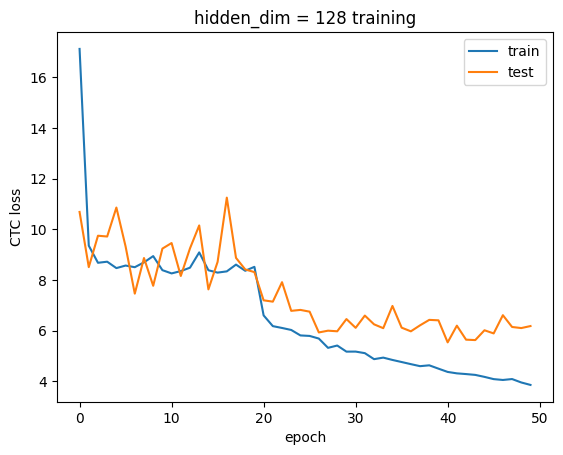

In [ ]:
hidden_dim = 128   # bumped from 64 — everything else stays the same

params = init_rnn_params(input_dim, hidden_dim, vocab_size)
adam_state = init_adam_state(params)
train_loss_history = []
test_loss_history = []

def run_epoch(lr):
    random.shuffle(train_data)
    epoch_loss = 0.0
    for spec_feat, enc_label in train_data:
        loss = train_step(spec_feat, enc_label, params, blank_idx, adam_state, lr=lr)
        epoch_loss += loss
    return epoch_loss / len(train_data)

# phase 1: steady lr, cover ground fast
for epoch in range(20):
    train_loss = run_epoch(lr=0.01)
    test_loss = evaluate_loss_fixed(params, blank_idx)
    train_loss_history.append(train_loss)
    test_loss_history.append(test_loss)
    print(f'epoch {epoch:2d}  lr 0.01000  train {train_loss:.4f}  test {test_loss:.4f}')
    np.savez('ctc_rnn_checkpoint_h128.npz', **params)

# phase 2: decay to settle precisely, same trick that fixed the plateau earlier
for i in range(30):
    lr = 0.005 * (0.96 ** i)
    train_loss = run_epoch(lr=lr)
    test_loss = evaluate_loss_fixed(params, blank_idx)
    train_loss_history.append(train_loss)
    test_loss_history.append(test_loss)
    print(f'epoch {20+i:2d}  lr {lr:.5f}  train {train_loss:.4f}  test {test_loss:.4f}')
    np.savez('ctc_rnn_checkpoint_h128.npz', **params)

plt.plot(train_loss_history, label='train')
plt.plot(test_loss_history, label='test')
plt.xlabel('epoch'); plt.ylabel('CTC loss'); plt.legend()
plt.title('hidden_dim = 128 training')
plt.show()

In [ ]:
show_predictions_beam(test_data, params, n=10)
cer, acc = compute_cer_beam(eval_subset, params)
print(f'CER: {cer:.3f}   exact match: {acc:.3f}')

  true: three     greedy: tone      beam: tone
  true: five      greedy: fiur      beam: fiur
  true: zero      greedy: fir       beam: fir
  true: seven     greedy: thren     beam: thren
  true: six       greedy: sire      beam: sir
  true: two       greedy: inr       beam: inr
✓ true: one       greedy: one       beam: one
✓ true: nine      greedy: nine      beam: nine
  true: zero      greedy: eiur      beam: eiur
✓ true: five      greedy: five      beam: five
CER: 0.406   exact match: 0.420


In [ ]:
print("start the Test From Here!.. ")

start the Test From Here!.. 


In [59]:
from google.colab import files
uploaded = files.upload()

Saving my_seven_v1.wav to my_seven_v1.wav


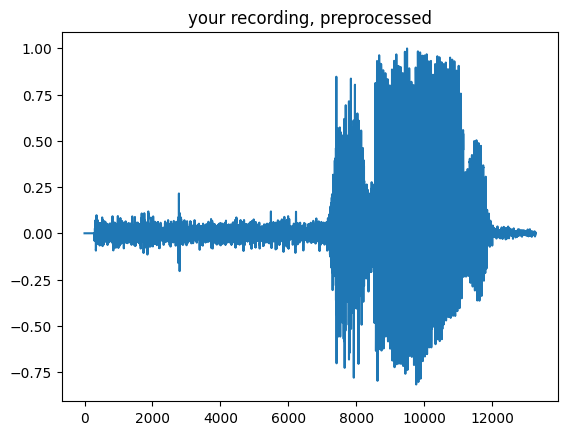

In [60]:
def load_any_wav(path):
    with wave.open(path, 'rb') as wf:
        sample_rate = wf.getframerate()
        n_channels = wf.getnchannels()
        raw_bytes = wf.readframes(wf.getnframes())
    samples = np.frombuffer(raw_bytes, dtype=np.int16)
    if n_channels > 1:
        samples = samples.reshape(-1, n_channels).mean(axis=1)   # collapse to mono
    return samples.astype(np.float32) / 32768.0, sample_rate

def resample(waveform, orig_sr, target_sr):
    duration = len(waveform) / orig_sr
    target_len = int(duration * target_sr)
    orig_idx = np.arange(len(waveform))
    target_idx = np.linspace(0, len(waveform) - 1, num=target_len)
    return np.interp(target_idx, orig_idx, waveform)   # simple linear-interpolation resampler

def trim_silence(waveform, threshold=0.03, pad=800):
    above = np.where(np.abs(waveform) > threshold)[0]
    if len(above) == 0:
        return waveform
    start = max(0, above[0] - pad)
    end = min(len(waveform), above[-1] + pad)
    return waveform[start:end]

my_path = list(uploaded.keys())[0]
raw_wave, raw_sr = load_any_wav(my_path)
wave_8k = resample(raw_wave, raw_sr, 8000)
wave_trimmed = trim_silence(wave_8k)

plt.plot(wave_trimmed)
plt.title('your recording, preprocessed')
plt.show()

In [61]:
my_spec = compute_spectrogram(wave_trimmed, sample_rate=8000)
probs, logits, _ = rnn_forward(my_spec, params)

print('greedy:', greedy_decode(probs, blank_idx, idx_to_char))
print('beam:  ', beam_search_decode(probs, blank_idx, idx_to_char, beam_width=10))

greedy: onet
beam:   onett


In [62]:
for fname in uploaded.keys():
    raw_wave, raw_sr = load_any_wav(fname)
    wave_8k = resample(raw_wave, raw_sr, 8000)
    wave_trimmed = trim_silence(wave_8k)
    spec_feat = compute_spectrogram(wave_trimmed, sample_rate=8000)
    probs, logits, _ = rnn_forward(spec_feat, params)
    greedy = greedy_decode(probs, blank_idx, idx_to_char)
    beam = beam_search_decode(probs, blank_idx, idx_to_char, beam_width=10)
    print(f'{fname:20s}  greedy: {greedy:10s}  beam: {beam}')

my_seven_v1.wav       greedy: onet        beam: onett


In [64]:
fsdd_spec = train_data[0][0]   # already-computed FSDD training example
print('FSDD   -> mean=%.4f std=%.4f min=%.4f max=%.4f' %
      (fsdd_spec.mean(), fsdd_spec.std(), fsdd_spec.min(), fsdd_spec.max()))

my_wave, my_sr = load_any_wav('my_seven_v1.wav')
my_wave_8k = resample(my_wave, my_sr, 8000)
my_wave_trimmed = trim_silence(my_wave_8k)
my_spec = compute_spectrogram(my_wave_trimmed, sample_rate=8000)
print('Yours  -> mean=%.4f std=%.4f min=%.4f max=%.4f' %
      (my_spec.mean(), my_spec.std(), my_spec.min(), my_spec.max()))

FSDD   -> mean=0.1251 std=0.2465 min=0.0001 max=2.3499
Yours  -> mean=0.2810 std=0.4202 min=0.0000 max=3.1772


In [65]:
import random as _random

test_filename = _random.choice(os.listdir(recordings_dir))
print('testing on:', test_filename)

wav, sr = load_wav(os.path.join(recordings_dir, test_filename))
spec_feat = compute_spectrogram(wav, sample_rate=sr)
probs, logits, _ = rnn_forward(spec_feat, params)

true_digit = test_filename.split('_')[0]
true_word = digit_to_word[true_digit]

print('true: ', true_word)
print('greedy:', greedy_decode(probs, blank_idx, idx_to_char))
print('beam:  ', beam_search_decode(probs, blank_idx, idx_to_char, beam_width=10))

testing on: 5_nicolas_14.wav
true:  five
greedy: five
beam:   five
